# 0. Import Modules

In [ ]:
from unet_2.preprocessing import rasterize_vector, tile_image, distribute_files, clip_geotiffs
from config.paths import use
import geopandas as gpd
import rasterio
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import random

torch.__version__

'2.7.1+cu128'

In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:42:46_Pacific_Standard_Time_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [3]:
!nvidia-smi

Tue Sep 23 16:53:45 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.83                 Driver Version: 572.83         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4070 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
| 33%   35C    P8             12W /  285W |    3039MiB /  12282MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# 1. Generate Training Dataset

## 1.1 Get info on data

In [4]:
from config.paths import use
import geopandas as gpd
import rasterio

reserves = ['BUS', 'KAU', 'ESK', 'WAI', 'HAM']


for r in use(reserves):
    # Load the vector data
    vector_path = os.path.join(r.GIS, 'swamp_maire_poly.gpkg')
    layer = 'maire_poly_ms'
    gdf = gpd.read_file(vector_path, layer=layer)

    # Get the vector CRS
    vector_crs = gdf.crs
    print(f"Vector CRS: {vector_crs}")

    # Load the raster data
    with rasterio.open(r.P_MS_025) as src:
        raster_crs = src.crs
        print(f"Raster CRS: {raster_crs}")


Processing Reserves: 100%|██████████| 5/5 [00:00<00:00, 26.36it/s]

Vector CRS: EPSG:2193
Raster CRS: EPSG:2193
Vector CRS: EPSG:2193
Raster CRS: EPSG:2193
Vector CRS: EPSG:2193
Raster CRS: EPSG:2193
Vector CRS: EPSG:2193
Raster CRS: EPSG:2193
Vector CRS: EPSG:2193
Raster CRS: EPSG:2193


## 1.2 Rasterize the Maire Areas

In [3]:
from config.paths import use
import geopandas as gpd
import rasterio
from unet.preprocessing import rasterize_vector, tile_image, distribute_files, clip_geotiffs
import time

reserves = ['KAU']


for r in use(reserves):
    
    # Load the vector data
    label_gpkg = os.path.join(r.GIS, 'swamp_maire_poly.gpkg')
    label_layer = 'maire_poly'

    training_zone_gpkg = os.path.join(r.GIS, 'bbox.gpkg')
    training_zone_layer = 'bbox'
    bands = [r.P_MS_G, r.P_MS_R, r.P_MS_RE, r.P_MS_NIR]
    rasterized_label = os.path.join(r.DS_UNET, 'maire.tif')

    tile_size = 576

    # Rasterize the vector
    rasterized = rasterize_vector(label_gpkg, label_layer, bands[0], rasterized_label)
    training_dataset_dir = os.path.join(r.DS_UNET, 'ms_test')
    training_images_dir = os.path.join(training_dataset_dir, f'aerial_{tile_size}')
    training_label_dir = os.path.join(training_dataset_dir, f'label_{tile_size}')

    tile_image(gdf_path = training_zone_gpkg,
           layer=training_zone_layer,
           tif_paths = bands,
           output_dir = training_images_dir,
           file_prefix=f'{r.name}_',
           tile_size=tile_size) # might need to change this to 512??? https://debuggercafe.com/training-unet-from-scratch/ 

    clip_geotiffs(rasterized_label,
              reference_dir = training_images_dir,
              output_dir = training_label_dir) 

    distribute_files(dataset_dir = training_dataset_dir,
                 folders=['train', 'valid'],
                 distribution=[0.8, 0.2],
                 image_folder=f'aerial_{tile_size}',
                 label_folder=f'label_{tile_size}',
                 ignore_nomatch=False,
                 out_dir=os.path.join(training_dataset_dir, 'training_dataset'))

Rasterizing: 100%|██████████| 1/1 [00:00<00:00, 11.36tiles/s]


Rasterization complete. Output saved to d:\kqn7759\OneDrive - AUT University\MA\aa566b206b36b985ac2ad0e73eedfc197cc8d2ffc\4_1_modules\config\../../3_0_data\limited_extent\B_kauri_glen\F_datasets/unet\maire.tif


Processing Reserves: 100%|██████████| 1/1 [00:03<00:00,  3.43s/it]


## Create combined dataset

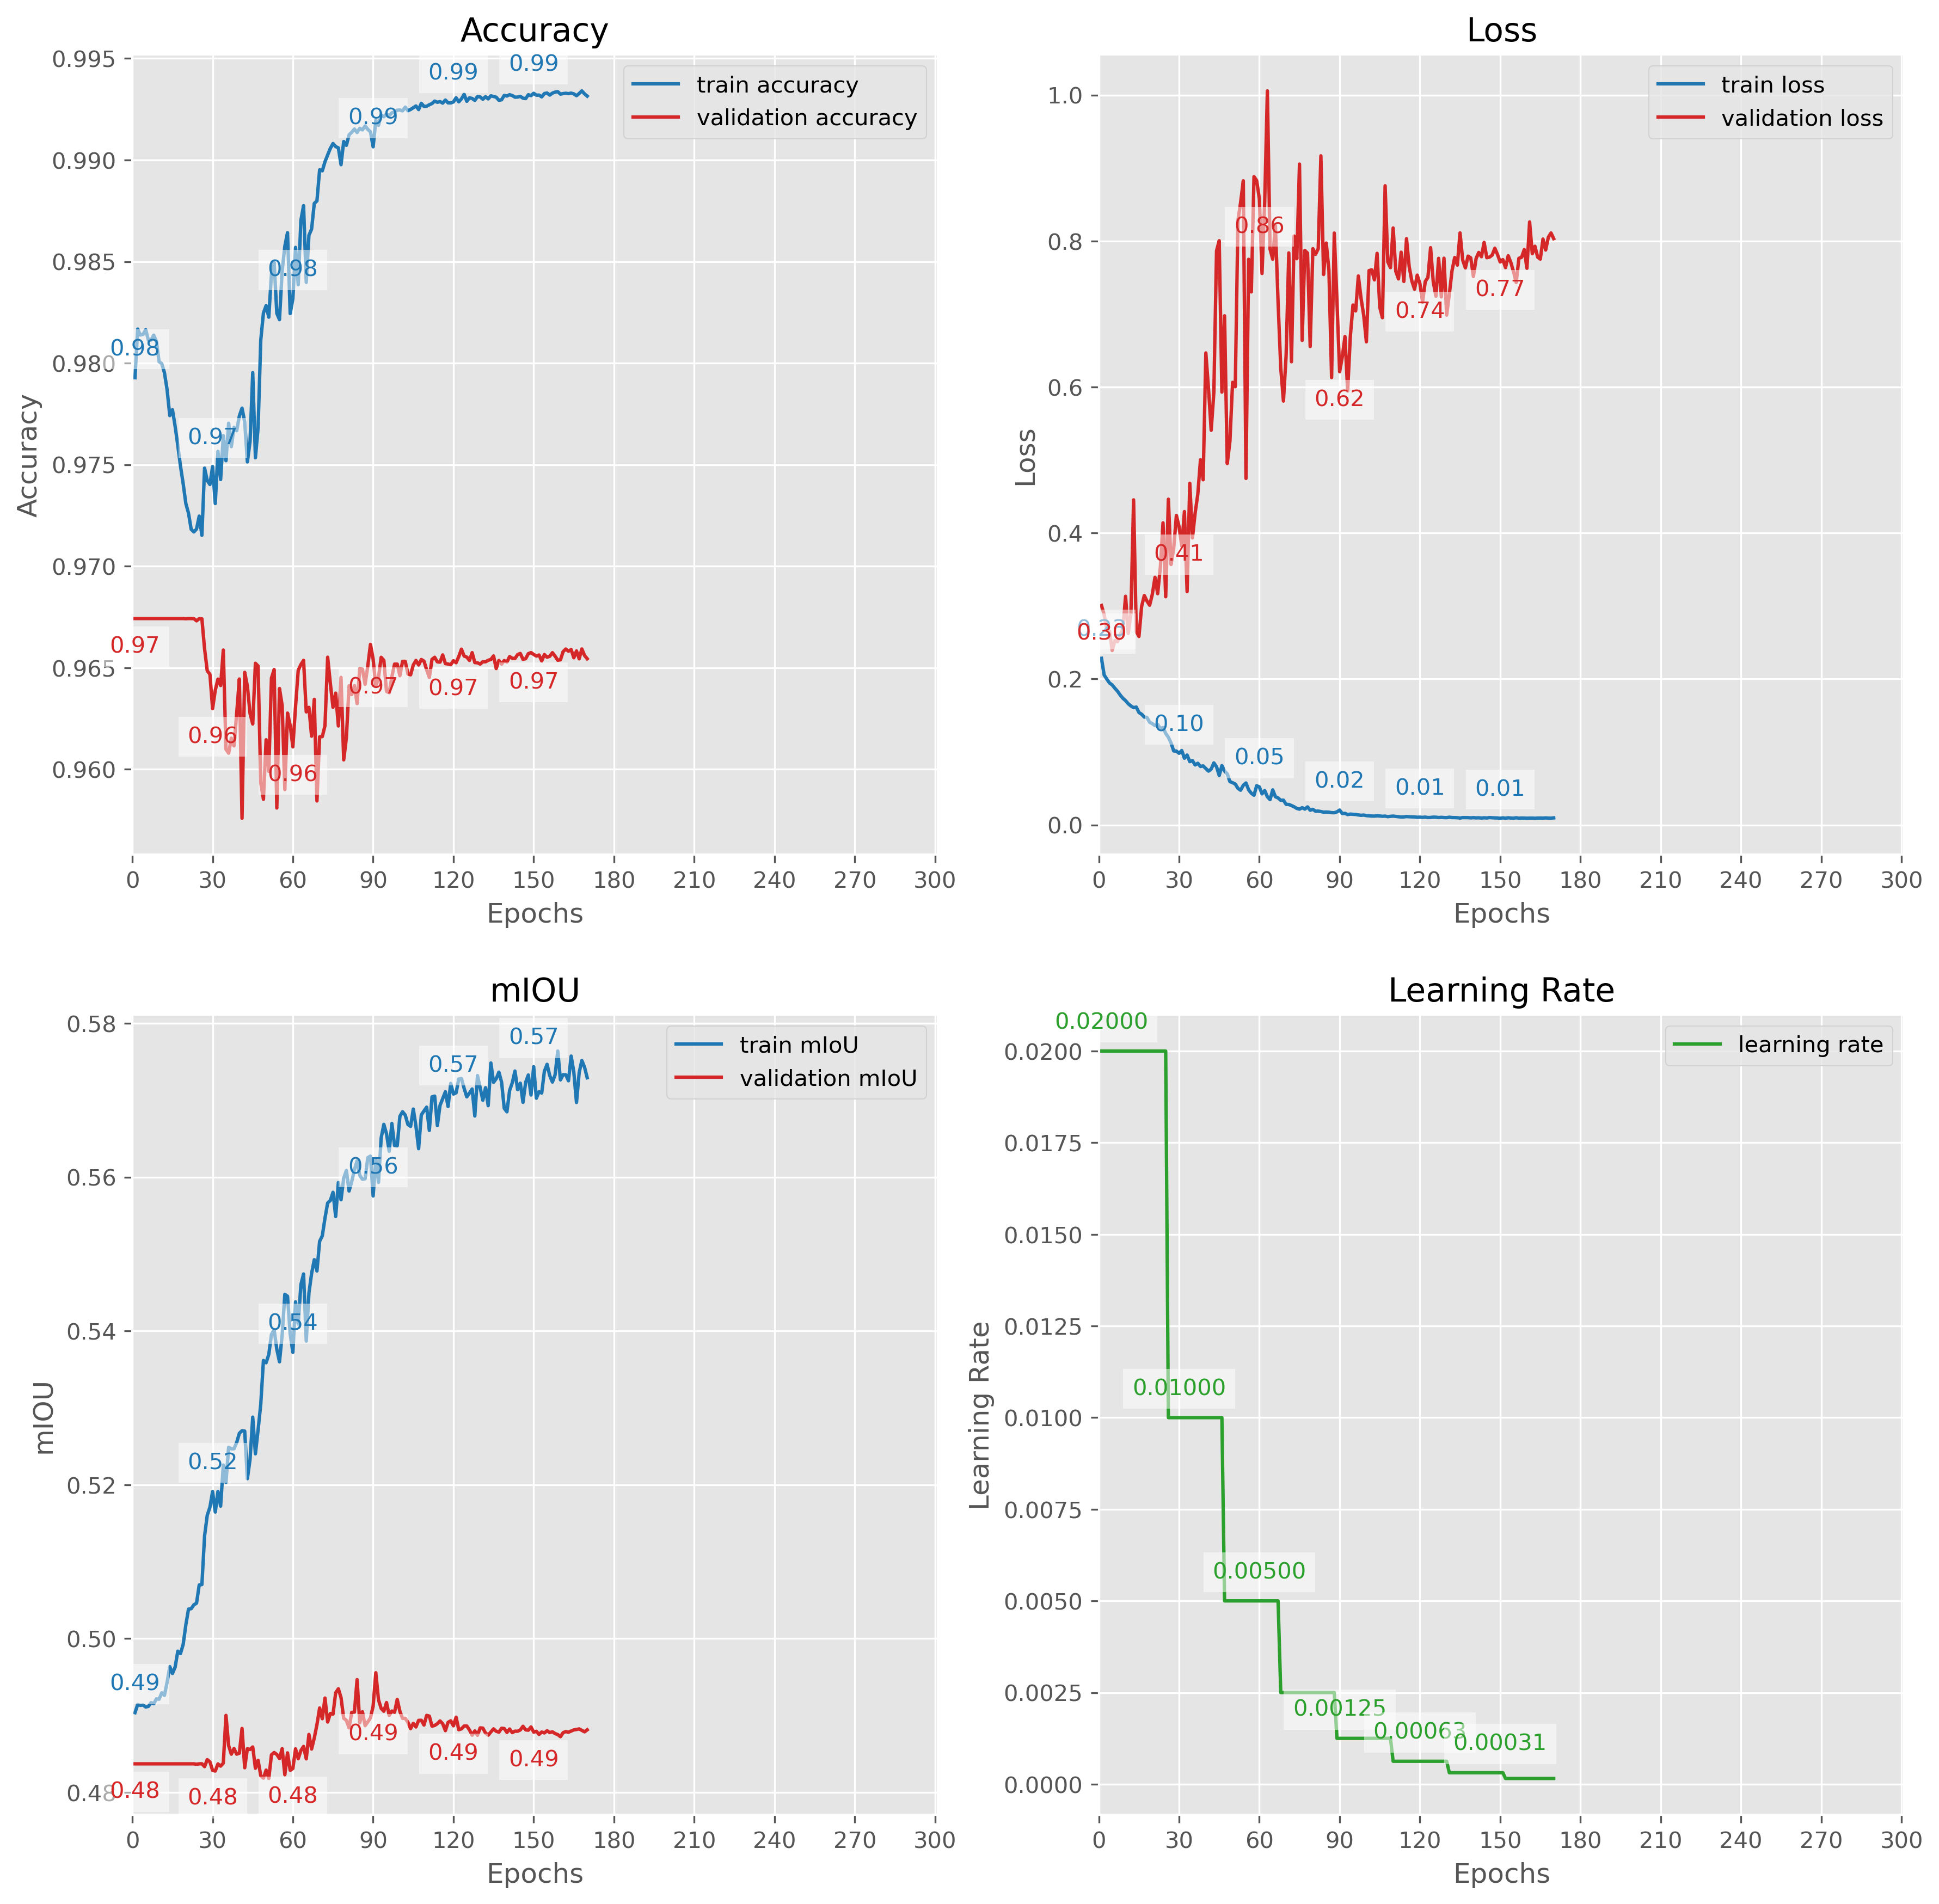

Early stopping triggered after 170 epochs.
TRAINING COMPLETE


In [ ]:
import os
import shutil
from utils.helper_functions import list_files, makedirs
from config.paths import use
from unet_2.preprocessing import rasterize_vector, tile_image, distribute_files, clip_geotiffs, distribute_files_with_target_balance
from unet_2.src.config import MAIRE_WEIGHT


list_reserves = [['ESK', 'KAU', 'BUS', 'HAM']]
# list_reserves = [['ESK'], ['KAU'], ['BUS'], ['HAM']]
# list_reserves = [['BUS']]

for reserves in list_reserves:
    tile_size = 576

    base_dataset_name = f"RGB_{'_'.join(reserves)}"

    # Final output directory for the training dataset only
    combined_dataset_dir = os.path.join('../../5_0_unet', base_dataset_name)
    training_dataset_dir = os.path.join(combined_dataset_dir, 'training_dataset')

    if not os.path.exists(training_dataset_dir):

        # Temporary merge directory for distribution
        temp_merge_dir = os.path.join(combined_dataset_dir, 'temp_merge')
        temp_images_dir = os.path.join(temp_merge_dir, f'aerial_{tile_size}')
        temp_labels_dir = os.path.join(temp_merge_dir, f'label_{tile_size}')
        makedirs(temp_images_dir)
        makedirs(temp_labels_dir)

        for r in use(reserves):
            label_gpkg = os.path.join(r.GIS, 'swamp_maire_poly.gpkg')
            label_layer = 'maire_poly_rgb'
            training_zone_gpkg = os.path.join(r.GIS, 'bbox.gpkg')
            training_zone_layer = 'unet_training_zone'
            #bands = [r.P_MS_RE, r.P_MS_NIR, r.P_IND_RENDVI] #, r.P_MS_SIPI, r.P_MS_GRI, r.P_MS_MRESR, r.P_MS_MCARI]
            bands = [r.P_RGB_R, r.P_RGB_G, r.P_RGB_B]
            bands = [r.P_MS_G, r.P_MS_R , r.P_MS_RE, r.P_MS_NIR]
            bands = bands + [os.path.join(r.P_IND, 'sep_rel', 'RENDVI_uint8.tif')]
            # bands = list_files(os.path.join(r.P_MS, 'sep_rel'), '_uint8.tif')# + bands
            # #bands = bands + [os.path.join(r.P_IND, 'sep_rel', 'NDVI_uint8.tif'), os.path.join(r.P_IND, 'sep_rel', 'NGRDI_uint8.tif'), os.path.join(r.P_IND, 'sep_rel', 'RENDVI_uint8.tif'), os.path.join(r.P_IND, 'sep_rel', 'REDVI_uint8.tif')]
            #print(bands)
            rasterized_label = os.path.join(r.DS_UNET, 'maire.tif')

            # Rasterize labels
            rasterized = rasterize_vector(label_gpkg, label_layer, bands[0], rasterized_label, 8192, training_zone_gpkg, training_zone_layer)

            # Reserve-specific output directories
            reserve_image_dir = os.path.join(r.DS_UNET, base_dataset_name, f'aerial_{tile_size}')
            reserve_label_dir = os.path.join(r.DS_UNET, base_dataset_name, f'label_{tile_size}')
            makedirs(reserve_image_dir, exist_ok=True)
            makedirs(reserve_label_dir, exist_ok=True)

            # Tile multispectral images
            tile_image(
                gdf_path=training_zone_gpkg,
                layer=training_zone_layer,
                tif_paths=bands,
                output_dir=reserve_image_dir,
                file_prefix=f'{r.name}_',
                tile_size=tile_size,
                clear_dir=True
            )

            # Clip rasterized label to match image tiles
            clip_geotiffs(
                rasterized_label,
                reference_dir=reserve_image_dir,
                output_dir=reserve_label_dir
            )

            # Link tiles and labels into temp merge dir
            for f in os.listdir(reserve_image_dir):
                src = os.path.join(reserve_image_dir, f)
                dst = os.path.join(temp_images_dir, f)
                if not os.path.exists(dst):
                    os.link(src, dst)

            for f in os.listdir(reserve_label_dir):
                src = os.path.join(reserve_label_dir, f)
                dst = os.path.join(temp_labels_dir, f)
                if not os.path.exists(dst):
                    os.link(src, dst)

        # Distribute the combined dataset
        distribute_files_with_target_balance(
            dataset_dir=temp_merge_dir,
            folders=['train', 'valid'],
            distribution=[0.8, 0.2],
            image_folder=f'aerial_{tile_size}',
            label_folder=f'label_{tile_size}',
            ignore_nomatch=False,
            out_dir=training_dataset_dir
        )

        # Clean up temp merge dir
        shutil.rmtree(temp_merge_dir)

    import torch
    import torch.nn as nn
    import os
    from unet_2.src.datasets import get_images, get_dataset, get_data_loaders
    from unet_2.src.engine import train_model
    from unet_2.src.model import UNet
    from unet_2.src.config import ALL_CLASSES, LABEL_COLORS_LIST, DEVICE, CLASS_WEIGHTS
    from unet_2.src.utils import SaveBestModel, SaveBestModelIOU, load_model

    from torch.optim.lr_scheduler import ReduceLROnPlateau

    from raster.utils import get_num_bands
    from utils.helper_functions import list_files
    from config.paths import use
    import geopandas as gpd
    import rasterio


    seed = 42
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True
    epochs = 300
    lr = 0.02
    batch_size = 2
    img_size = None
    use_scheduler = True


    model_name = fr"outputs_1_{int(MAIRE_WEIGHT)}_lr_{str(lr)}"

    out_dir = os.path.join(combined_dataset_dir, model_name)
    makedirs(out_dir, delete_if_exists=False, exist_ok=False)
    in_channels = get_num_bands(list_files(combined_dataset_dir, '.tif', True)[0])

    model = UNet(in_channels=in_channels , num_classes=len(ALL_CLASSES)).to(DEVICE)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS)

    train_images, train_masks, valid_images, valid_masks = get_images(root_path=training_dataset_dir)
    classes_to_train = ALL_CLASSES

    train_dataset, valid_dataset = get_dataset(
        train_images, train_masks, valid_images, valid_masks,
        ALL_CLASSES, classes_to_train, LABEL_COLORS_LIST, img_size=img_size
    )

    train_dataloader, valid_dataloader = get_data_loaders(train_dataset, valid_dataset, batch_size=batch_size)

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20, threshold=0.00001, threshold_mode='rel', cooldown=0, min_lr=0, eps=1e-08)

    state = train_model(model, train_dataset, train_dataloader, valid_dataset, valid_dataloader, optimizer, criterion, scheduler, epochs, out_dir)



# 2. Load Training Dataset

## 2.1 Import packages, functions and variables

# 2 Set parameters and Train Model

## 3.1 Alternatively continue from a checkpoint

In [ ]:
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

# To resume training from a checkpoint
model_path = os.path.join(out_dir, 'last_model.pth')
model, criterion, state, optimizer = load_model(model_path, optimizer)

epochs = 18 #total amount of epochs to train the model (previous epochs + new epochs)

# Continue training from the loaded state
state = train_model(model, train_dataset, train_dataloader, valid_dataset, valid_dataloader, optimizer, criterion, scheduler, epochs, out_dir, use_scheduler=True, patience=20, state=state)

# 5 Run model in inference

In [7]:
from unet.src.engine import make_predictions
from unet.postprocessing import copy_metadata, merge_geotiffs
from config.paths import use
from unet.preprocessing import tile_image
from unet_2.src.config import MAIRE_WEIGHT
from utils.helper_functions import list_files


list_reserves = [['BUS'], ['KAU'], ['ESK'], ['HAM']]
# list_reserves = [['HAM']]
lr = 0.02
for reserves in list_reserves:
    model_name = fr"outputs_1_{int(MAIRE_WEIGHT)}_lr_{str(lr)}"
    model_type = 'best_model_iou'
    backup_model_type = 'best_model_loss'
    backup_model_type_2 = 'last_model'
    #model_type = 'last_model'
    base_dataset_name = f"REL_MS_RENDVI_{'_'.join(reserves)}"
    model_path =  fr'../../5_0_unet/{base_dataset_name}/{model_name}/{model_type}.pth'
    backup_model_path =  fr'../../5_0_unet/{base_dataset_name}/{model_name}/{backup_model_type}.pth'
    backup_model_path_2 =  fr'../../5_0_unet/{base_dataset_name}/{model_name}/{backup_model_type_2}.pth'
    
    #reserves = ['ESK', 'KAU', 'BUS', 'HAM', 'WAI']

    for r in use(reserves):

        tile_size = 576
        training_zone_gpkg = os.path.join(r.GIS, 'bbox.gpkg')
        training_zone_layer = 'bbox'
        #bands = [r.P_MS_RE, r.P_MS_NIR, r.P_IND_RENDVI]#, r.P_MS_SIPI, r.P_MS_GRI, r.P_MS_MRESR, r.P_MS_MCARI]
        #bands = [r.P_MS_G, r.P_MS_R , r.P_MS_RE, r.P_MS_NIR, r.P_IND_RENDVI]#, r.P_MS_SIPI, r.P_MS_GRI, r.P_MS_MRESR, r.P_MS_MCARI]
        #bands = list_files(r.P_MS, '_uint8.tif') #+ bands
        #bands = [r.P_RGB_R, r.P_RGB_G, r.P_RGB_B]
        bands = list_files(os.path.join(r.P_MS, 'sep_rel'), '_uint8.tif')# + bands
        bands = bands + [os.path.join(r.P_IND, 'sep_rel', 'NDVI_uint8.tif'), os.path.join(r.P_IND, 'sep_rel', 'NGRDI_uint8.tif'), os.path.join(r.P_IND, 'sep_rel', 'RENDVI_uint8.tif'), os.path.join(r.P_IND, 'sep_rel', 'REDVI_uint8.tif')]        # Reserve-specific output directories
        
        bands = list_files(os.path.join(r.P_MS, 'sep_rel'), '_uint8.tif')# + bands
        #bands = bands + [os.path.join(r.P_IND, 'sep_rel', 'NDVI_uint8.tif'), os.path.join(r.P_IND, 'sep_rel', 'NGRDI_uint8.tif'), os.path.join(r.P_IND, 'sep_rel', 'RENDVI_uint8.tif'), os.path.join(r.P_IND, 'sep_rel', 'REDVI_uint8.tif')]
        bands = bands + [os.path.join(r.P_IND, 'sep_rel', 'RENDVI_uint8.tif')]
    
        out_dir = os.path.join(r.DS_UNET, base_dataset_name, model_name)
        tiles_dir = os.path.join(out_dir, f'aerial_{tile_size}')
        preds_dir = os.path.join(out_dir, 'predictions')
        os.makedirs(tiles_dir, exist_ok=True)
        os.makedirs(preds_dir, exist_ok=True)

        # Tile multispectral images
        tile_image(
            gdf_path=training_zone_gpkg,
            layer=training_zone_layer,
            tif_paths=bands,
            output_dir=tiles_dir,
            file_prefix=f'{r.name}_',
            tile_size=tile_size,
            clear_dir=True
        )




        pred_tiles_dir = os.path.join(preds_dir, 'tiles')
        out_tif = os.path.join(preds_dir, f'{model_type}.tif')
        try:
            make_predictions(tiles_dir, model_path, pred_tiles_dir)
        except Exception as e:
            print(f"Failed to make predictions with {model_type} for reserve {r.name}: {e}")
            print(f"Attempting to use backup model: {backup_model_type}")
            try:
                make_predictions(tiles_dir, backup_model_path, pred_tiles_dir)
            except Exception as e:
                make_predictions(tiles_dir, backup_model_path_2, pred_tiles_dir)
        copy_metadata(rgb_dir=tiles_dir, gray_dir=pred_tiles_dir)
        # merge the individual tiles to retrieve a single output file
        merge_geotiffs(pred_tiles_dir, out_tif)


100%|██████████| 1/1 [00:02<00:00,  2.47s/it]:00<?, ?it/s]


Failed to make predictions with best_model_iou for reserve KAU: [Errno 2] No such file or directory: '../../5_0_unet/REL_MS_RENDVI_KAU/outputs_1_10_lr_0.02/best_model_iou.pth'
Attempting to use backup model: best_model_loss


Processing Reserves: 100%|██████████| 1/1 [00:06<00:00,  6.70s/it]
